# Türk İşaret Dili Tanıma, BiLSTM Modeli
**Yapı:** `ErenDataset/train`, `/val`, `/test` → kelime klasörleri → `.npy` dosyaları

## Genel Amac
AUTSL veri setinden MediaPipe ile cikarilan .npy koordinat dosyalarini kullanarak
Turk Isaretci Dili tanima modeli egitmek.

## Veri
- ErenDataset/ altinda train/val/test klasorleri
- Her .npy dosyasi: (frame_sayisi, 170) shape, float32
- 30 sinif, train ~123/sinif, val ~19/sinif, test ~16/sinif
- Padding degeri: -1.0 (MediaPipe koordinatlari 0-1 arasi oldugu icin cakisma yok)
- MAX_SEQ_LEN: 82 (train setinin %95 persentili)
- Normalizasyon: sadece gercek frame'ler uzerinden (train mean/std, -1 padding korunuyor)

## 1. Kurulum ve Drive Bağlantısı

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import os
import glob
from collections import defaultdict
import matplotlib.pyplot as plt

DATASET_ROOT = '/content/data'
OUTPUT_ROOT  = '/content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset'

TRAIN_PATH = os.path.join(DATASET_ROOT, 'train')
VAL_PATH   = os.path.join(DATASET_ROOT, 'val')
TEST_PATH  = os.path.join(DATASET_ROOT, 'test')

print('Train yolu:', TRAIN_PATH)
print(os.path.exists(TRAIN_PATH))

Train yolu: /content/data/train
False


In [2]:
import subprocess, os, shutil
import pandas as pd

DRIVE_ROOT  = '/content/drive/MyDrive/Nöron-Ağları-Proje'
TMP_DIR     = '/content/sign_samples_tmp'
OUTPUT_DIR  = f'{DRIVE_ROOT}/ErenDataset/sign_samples'
os.makedirs(TMP_DIR,    exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

our_classes = [
    '0_ben', '1_sen', '2_selam', '3_hoscakal', '4_tamam',
    '5_evet', '6_hayir', '7_tesekkur', '8_rica_etmek', '9_ozur_dilemek',
    '10_var', '11_yok', '12_iyi', '13_kotu', '14_nasil',
    '15_neden', '16_nerede', '17_yardim', '18_doktor', '19_hasta',
    '20_hastane', '21_ilac', '22_gecmis_olsun', '23_ataturk', '24_ev',
    '25_zaman', '26_icmek', '27_yemek', '28_yapmak', '29_bakmak'
]

df = pd.read_csv(f'{DRIVE_ROOT}/Train/train_labels.csv',
                 header=None, names=['filename', 'label'])

ok, skip, err = 0, 0, 0

for label_id, cls_name in enumerate(our_classes):
    dest = os.path.join(OUTPUT_DIR, f'{cls_name}.mp4')
    if os.path.exists(dest):
        print(f'[ATLA]  {cls_name}')
        skip += 1
        continue

    rows = df[df['label'] == label_id]
    if len(rows) == 0:
        print(f'[YOK]   {cls_name}')
        err += 1
        continue

    fname        = rows.iloc[0]['filename']
    video_name   = f'{fname}_color.mp4'
    zip_internal = f'train/{video_name}'
    local        = os.path.join(TMP_DIR, video_name)

    subprocess.run(
        ['7z', 'e', '-pMdG3z6Eh1t',
         f'{DRIVE_ROOT}/Train/train_set_vfbha39.zip.001',
         zip_internal, f'-o{TMP_DIR}', '-y'],
        capture_output=True
    )

    if not os.path.exists(local):
        print(f'[HATA]  {cls_name} → {video_name}')
        err += 1
        continue

    shutil.copy2(local, dest)
    os.remove(local)
    print(f'[OK]    {cls_name}.mp4')
    ok += 1

shutil.rmtree(TMP_DIR)  # temp klasörü temizle
print(f'\nTamamlandı → OK:{ok}  Atlandı:{skip}  Hata:{err}')
print(f'Konum: {OUTPUT_DIR}')

[OK]    0_ben.mp4
[OK]    1_sen.mp4
[OK]    2_selam.mp4
[OK]    3_hoscakal.mp4
[OK]    4_tamam.mp4
[OK]    5_evet.mp4
[OK]    6_hayir.mp4
[OK]    7_tesekkur.mp4
[OK]    8_rica_etmek.mp4
[OK]    9_ozur_dilemek.mp4
[OK]    10_var.mp4
[OK]    11_yok.mp4
[OK]    12_iyi.mp4
[OK]    13_kotu.mp4
[OK]    14_nasil.mp4
[OK]    15_neden.mp4
[OK]    16_nerede.mp4
[OK]    17_yardim.mp4
[OK]    18_doktor.mp4
[OK]    19_hasta.mp4
[OK]    20_hastane.mp4
[OK]    21_ilac.mp4
[OK]    22_gecmis_olsun.mp4
[OK]    23_ataturk.mp4
[OK]    24_ev.mp4
[OK]    25_zaman.mp4
[OK]    26_icmek.mp4
[OK]    27_yemek.mp4
[OK]    28_yapmak.mp4
[OK]    29_bakmak.mp4

Tamamlandı → OK:30  Atlandı:0  Hata:0
Konum: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/sign_samples


In [ ]:
import zipfile, os
from tqdm.notebook import tqdm

zip_path  = '/content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset_data.zip'
dest_path = '/content/data'

if not os.path.exists(f'{dest_path}/train'):
    os.makedirs(dest_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = zf.namelist()
        for member in tqdm(members, desc='Zip aciliyor', unit='dosya'):
            zf.extract(member, dest_path)
    print('Tamamlandi')
else:
    print('Veri zaten mevcut, atlaniyor')

Zip aciliyor:   0%|          | 0/4861 [00:00<?, ?dosya/s]

Tamamlandi


## 2. Veri Keşfi

In [ ]:
# Tüm kelime sınıflarını bul (train'den)
classes = sorted(os.listdir(TRAIN_PATH))
num_classes = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}

print(f'Toplam sınıf sayısı: {num_classes}')
print(f'Sınıflar: {classes}')

Toplam sınıf sayısı: 30
Sınıflar: ['0_ben', '10_var', '11_yok', '12_iyi', '13_kotu', '14_nasil', '15_neden', '16_nerede', '17_yardim', '18_doktor', '19_hasta', '1_sen', '20_hastane', '21_ilac', '22_gecmis_olsun', '23_ataturk', '24_ev', '25_zaman', '26_icmek', '27_yemek', '28_yapmak', '29_bakmak', '2_selam', '3_hoscakal', '4_tamam', '5_evet', '6_hayir', '7_tesekkur', '8_rica_etmek', '9_ozur_dilemek']


In [ ]:
# Her split için dosya sayısını say
for split_name, split_path in [('TRAIN', TRAIN_PATH), ('VAL', VAL_PATH), ('TEST', TEST_PATH)]:
    total = 0
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            n = len(glob.glob(os.path.join(cls_path, '*.npy')))
            total += n
    print(f'{split_name}: {total} dosya')

TRAIN: 3696 dosya
VAL: 578 dosya
TEST: 494 dosya


In [ ]:
from collections import defaultdict

counts = defaultdict(int)
for cls in classes:
    counts[cls] = len(glob.glob(os.path.join(TRAIN_PATH, cls, '*.npy')))

for cls, cnt in sorted(counts.items(), key=lambda x: x[1]):
    bar = '█' * (cnt // 5)
    print(f"{cls:25s} {cnt:4d} {bar}")

print(f"\nMin: {min(counts.values())}, Max: {max(counts.values())}, Toplam: {sum(counts.values())}")

16_nerede                  108 █████████████████████
14_nasil                   119 ███████████████████████
18_doktor                  120 ████████████████████████
19_hasta                   120 ████████████████████████
10_var                     121 ████████████████████████
15_neden                   121 ████████████████████████
23_ataturk                 121 ████████████████████████
22_gecmis_olsun            122 ████████████████████████
7_tesekkur                 122 ████████████████████████
9_ozur_dilemek             122 ████████████████████████
17_yardim                  123 ████████████████████████
24_ev                      123 ████████████████████████
2_selam                    123 ████████████████████████
3_hoscakal                 123 ████████████████████████
13_kotu                    124 ████████████████████████
1_sen                      125 █████████████████████████
20_hastane                 125 █████████████████████████
21_ilac                    125 ███████████████████

In [ ]:
# İlk sınıfın ilk dosyasını oku
sample_class = classes[0]
sample_files = glob.glob(os.path.join(TRAIN_PATH, sample_class, '*.npy'))
sample_data  = np.load(sample_files[0])

print(f'Örnek dosya: {os.path.basename(sample_files[0])}')
print(f'Shape      : {sample_data.shape}')
print(f'Dtype      : {sample_data.dtype}')
print(f'Min / Max  : {sample_data.min():.4f} / {sample_data.max():.4f}')
print()
print('→ (frame_sayısı, özellik_boyutu) şeklinde olmalı')

# Global olarak kaydet
NUM_FEATURES = sample_data.shape[-1]  # özellik boyutu
print(f'\nÖzellik boyutu (NUM_FEATURES): {NUM_FEATURES}')

Örnek dosya: signer33_sample398_color.npy
Shape      : (71, 170)
Dtype      : float32
Min / Max  : -0.7500 / 0.9999

→ (frame_sayısı, özellik_boyutu) şeklinde olmalı

Özellik boyutu (NUM_FEATURES): 170


Frame sayısı — Min: 36, Max: 122, Ort: 65.0, Medyan: 64


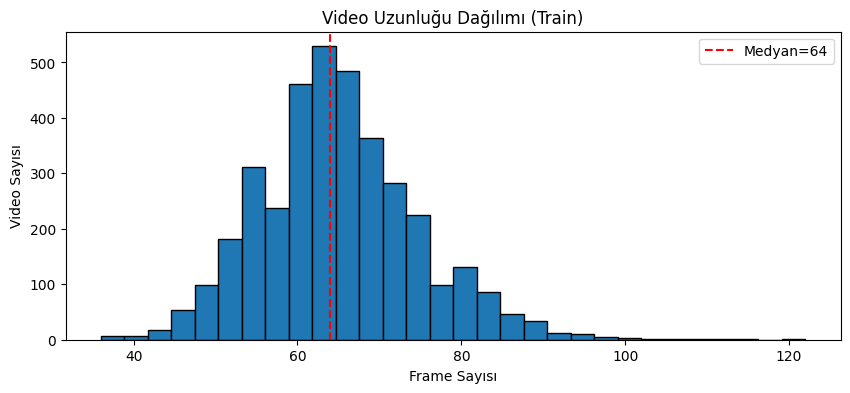

In [ ]:
# Tüm videolardaki frame sayısı dağılımını gör
all_lengths = []
for cls in classes:
    for fpath in glob.glob(os.path.join(TRAIN_PATH, cls, '*.npy')):
        d = np.load(fpath)
        all_lengths.append(d.shape[0])

print(f'Frame sayısı — Min: {min(all_lengths)}, Max: {max(all_lengths)}, Ort: {np.mean(all_lengths):.1f}, Medyan: {np.median(all_lengths):.0f}')

plt.figure(figsize=(10,4))
plt.hist(all_lengths, bins=30, edgecolor='black')
plt.xlabel('Frame Sayısı')
plt.ylabel('Video Sayısı')
plt.title('Video Uzunluğu Dağılımı (Train)')
plt.axvline(np.median(all_lengths), color='red', linestyle='--', label=f'Medyan={int(np.median(all_lengths))}')
plt.legend()
plt.show()

In [ ]:
import numpy as np
print(f'%95 persentil: {int(np.percentile(all_lengths, 95))}')
print(f'%99 persentil: {int(np.percentile(all_lengths, 99))}')

%95 persentil: 82
%99 persentil: 91


## 3. Veri Yükleme, Padding ve Normalizasyon

In [ ]:
MAX_SEQ_LEN = int(np.percentile(all_lengths, 95))
print(f'MAX_SEQ_LEN  = {MAX_SEQ_LEN} (frame sayısı)')
print(f'NUM_FEATURES = {NUM_FEATURES}')
print(f'NUM_CLASSES  = {num_classes}')

MAX_SEQ_LEN  = 82 (frame sayısı)
NUM_FEATURES = 170
NUM_CLASSES  = 30


In [ ]:
config = {
    'experiment': {
        'name' : 'bilstm_attention',
        'notes': 'Dropout 0.5 + L2 + Label Smoothing',
    },
    'model': {
        'type'             : 'BiLSTM_Attention',
        'lstm_units'       : [256, 128],
        'dense_units'      : 128,
        'dropout'          : 0.5,
        'recurrent_dropout': 0.0,
        'l2'               : 0.001,
        'bidirectional'    : True,
    },
    'training': {
        'batch_size'              : 32,
        'epochs'                  : 100,
        'learning_rate'           : 0.001,
        'label_smoothing'         : 0.1,
        'early_stopping_patience' : 10,
        'reduce_lr_patience'      : 5,
        'reduce_lr_factor'        : 0.5,
        'min_lr'                  : 1e-6,
    },
    'augmentation': {
        'enabled'         : False,
        'gaussian_noise'  : {'enabled': False, 'std': 0.005},
        'temporal_scaling': {'enabled': False, 'min': 0.9, 'max': 1.1},
        'spatial_scaling' : {'enabled': False, 'min': 0.9, 'max': 1.1},
    },
    'data': {
        'max_seq_len'  : 82,
        'num_features' : 170,
        'num_classes'  : 30,
        'padding_value': -1.0,
        'train_path'   : TRAIN_PATH,
        'val_path'     : VAL_PATH,
        'test_path'    : TEST_PATH,
    }
}
print('Config hazir.')

Config hazir.


In [ ]:
from tqdm.notebook import tqdm

TRAIN_PATH = '/content/data/train'
VAL_PATH   = '/content/data/val'
TEST_PATH  = '/content/data/test'

def load_split(split_path, classes, class_to_idx, max_len, num_features, split_name=''):
    X_list, y_list = [], []

    all_files = []
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.exists(cls_path):
            print(f'{cls} klasörü bulunamadı, atlıyor.')
            continue
        for fpath in glob.glob(os.path.join(cls_path, '*.npy')):
            all_files.append((fpath, class_to_idx[cls]))

    for fpath, label in tqdm(all_files, desc=split_name, unit='dosya'):
        seq = np.load(fpath).astype(np.float32)

        if seq.ndim != 2 or seq.shape[1] != num_features:
            T = seq.shape[0] if seq.ndim == 2 else 1
            fixed = np.full((T, num_features), -1.0, dtype=np.float32)
            cols = min(seq.shape[-1] if seq.ndim == 2 else 0, num_features)
            if cols > 0:
                fixed[:, :cols] = seq[:, :cols]
            seq = fixed

        T = seq.shape[0]
        if T >= max_len:
            start = (T - max_len) // 2
            seq = seq[start:start + max_len]
        else:
            pad = np.full((max_len - T, num_features), -1.0, dtype=np.float32)
            seq = np.vstack([seq, pad])

        X_list.append(seq)
        y_list.append(label)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int32)

MAX_SEQ_LEN = 82

print('Veriler yükleniyor...')
X_train, y_train = load_split(TRAIN_PATH, classes, class_to_idx, MAX_SEQ_LEN, NUM_FEATURES, 'Train')
X_val,   y_val   = load_split(VAL_PATH,   classes, class_to_idx, MAX_SEQ_LEN, NUM_FEATURES, 'Val')
X_test,  y_test  = load_split(TEST_PATH,  classes, class_to_idx, MAX_SEQ_LEN, NUM_FEATURES, 'Test')

print(f'Train : X={X_train.shape}, y={y_train.shape}')
print(f'Val   : X={X_val.shape},   y={y_val.shape}')
print(f'Test  : X={X_test.shape},  y={y_test.shape}')

Veriler yükleniyor...


Train:   0%|          | 0/3696 [00:00<?, ?dosya/s]

Val:   0%|          | 0/578 [00:00<?, ?dosya/s]

Test:   0%|          | 0/494 [00:00<?, ?dosya/s]

Train : X=(3696, 82, 170), y=(3696,)
Val   : X=(578, 82, 170),   y=(578,)
Test  : X=(494, 82, 170),  y=(494,)


In [ ]:
# NaN / Inf kontrolü
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val   = np.nan_to_num(X_val,   nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

# Sadece gerçek frame'leri normalize et (padding -1 olanları atla)
mask_train = (X_train != -1.0).all(axis=-1)  # (N, T)
mask_val   = (X_val   != -1.0).all(axis=-1)
mask_test  = (X_test  != -1.0).all(axis=-1)

# Train istatistiklerini gerçek frame'lerden hesapla
real_frames = X_train[mask_train]  # (gerçek_frame_sayısı, 170)
mean = real_frames.mean(axis=0)    # (170,)
std  = real_frames.std(axis=0) + 1e-8

# Normalize et, padding -1 olarak kalsın
X_train = np.where(mask_train[..., np.newaxis], (X_train - mean) / std, -1.0)
X_val   = np.where(mask_val[..., np.newaxis],   (X_val   - mean) / std, -1.0)
X_test  = np.where(mask_test[..., np.newaxis],  (X_test  - mean) / std, -1.0)

print('Normalizasyon tamamlandı.')
print(f'Train mean≈{X_train[mask_train].mean():.4f}, std≈{X_train[mask_train].std():.4f}')

Normalizasyon tamamlandı.
Train mean≈-0.0007, std≈0.9992


In [ ]:
import tensorflow as tf
import numpy as np

def augment_sequence(seq, config):
    aug_cfg = config['augmentation']
    if not aug_cfg['enabled']:
        return seq

    if aug_cfg['temporal_scaling']['enabled']:
        scale = np.random.uniform(aug_cfg['temporal_scaling']['min'], aug_cfg['temporal_scaling']['max'])
        T = seq.shape[0]
        new_T = max(1, int(T * scale))
        indices = np.linspace(0, T - 1, new_T).astype(int)
        seq = seq[indices]

    if aug_cfg['spatial_scaling']['enabled']:
        scale = np.random.uniform(aug_cfg['spatial_scaling']['min'], aug_cfg['spatial_scaling']['max'])
        seq = seq * scale

    if aug_cfg['gaussian_noise']['enabled']:
        noise = np.random.normal(0, aug_cfg['gaussian_noise']['std'], seq.shape)
        seq = seq + noise

    return seq.astype(np.float32)


def pad_sequence(seq, max_len, num_features):
    T = seq.shape[0]
    if T >= max_len:
        start = (T - max_len) // 2
        return seq[start:start + max_len]
    else:
        pad = np.full((max_len - T, num_features), -1.0, dtype=np.float32)
        return np.vstack([seq, pad])


class AugmentedDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, X, y, config, augment=True, **kwargs):
        super().__init__(**kwargs)
        self.X            = X
        self.y            = y
        self.config       = config
        self.augment      = augment
        self.batch_size   = config['training']['batch_size']
        self.max_len      = config['data']['max_seq_len']
        self.num_features = config['data']['num_features']
        self.num_classes  = config['data']['num_classes']
        self.indices      = np.arange(len(X))
        if augment:
            np.random.shuffle(self.indices)  # başlangıçta shuffle

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch, y_batch = [], []

        for i in batch_idx:
            seq = self.X[i].copy()
            if self.augment and self.config['augmentation']['enabled']:
                real_mask = (seq != -1.0).any(axis=-1)
                real_seq  = seq[real_mask]
                real_seq  = augment_sequence(real_seq, self.config)
                seq       = pad_sequence(real_seq, self.max_len, self.num_features)
            X_batch.append(seq)
            y_batch.append(self.y[i])

        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = np.array(y_batch, dtype=np.int32)

        if self.augment and self.config['augmentation']['mixup']['enabled']:
            alpha    = self.config['augmentation']['mixup']['alpha']
            lam      = np.clip(np.random.beta(alpha, alpha), 0.4, 0.6)
            perm     = np.random.permutation(len(X_batch))
            y_onehot = np.eye(self.num_classes, dtype=np.float32)[y_batch]
            X_batch  = lam * X_batch + (1 - lam) * X_batch[perm]
            y_onehot = lam * y_onehot + (1 - lam) * y_onehot[perm]
            return X_batch, y_onehot

        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)


train_gen = AugmentedDataGenerator(X_train, y_train, config, augment=True)
val_gen   = AugmentedDataGenerator(X_val,   y_val,   config, augment=False)

print(f'Train generator: {len(train_gen)} batch')
print(f'Val generator  : {len(val_gen)} batch')
print(f'Mixup: {config["augmentation"]["mixup"]["enabled"]}')

Train generator: 116 batch
Val generator  : 19 batch
Mixup: True


In [ ]:
# 1. Shape kontrolu
batch_X, batch_y = train_gen[0]
print(f'Batch X shape : {batch_X.shape}')
print(f'Batch y shape : {batch_y.shape}')
assert batch_X.shape == (config['training']['batch_size'], config['data']['max_seq_len'], config['data']['num_features']), 'Shape hatasi!'
assert batch_y.shape == (config['training']['batch_size'], config['data']['num_classes']), 'Label shape hatasi!'
print('Shape: OK\n')

# 2. Padding kontrolu
pad_check = (batch_X == -1.0)
print(f'Padding (-1.0) var mi: {pad_check.any()}')
print('Padding: OK\n')

# 3. Mixup kontrolu
mixup_enabled = config['augmentation']['mixup']['enabled']
print(f'Label min: {batch_y.min():.4f}, max: {batch_y.max():.4f}')

if mixup_enabled:
    # lam 0.4-0.6 arasında clip edildiğinden max 0.6 civarında olmalı
    pure_labels  = (batch_y.max(axis=1) > 0.61).sum()
    mixed_labels = (batch_y.max(axis=1) <= 0.61).sum()
    print(f'Saf label   (max > 0.61): {pure_labels}')
    print(f'Karisik label (max <= 0.61): {mixed_labels}')
    assert mixed_labels > 0, 'Mixup calismıyor — hic karisik label yok!'
else:
    pure_labels  = (batch_y.max(axis=1) > 0.99).sum()
    mixed_labels = (batch_y.max(axis=1) <= 0.99).sum()
    print(f'Saf label (max > 0.99): {pure_labels}, Karisik label: {mixed_labels}')

print(f'Max label degerleri (ilk 5): {batch_y.max(axis=1)[:5].round(4)}')
assert np.allclose(batch_y.sum(axis=1), 1.0, atol=1e-5), 'Label toplami 1.0 degil!'
print('Mixup: OK\n')

# 4. Mixup X degerleri orijinalden farkli olmali
sample_orig = X_train[0].copy()
aug1 = batch_X[0]
print(f'Orijinal ilk frame ilk 5: {sample_orig[0, :5].round(4)}')
print(f'Mixup ilk frame ilk 5   : {aug1[0, :5].round(4)}')
print(f'Farkli mi: {not np.allclose(sample_orig[0], aug1[0])}')
print('X Mixup: OK\n')

# 5. Val generator mixup uygulamiyor mu — integer label olmali
val_batch_X, val_batch_y = val_gen[0]
print(f'Val label shape: {val_batch_y.shape}')
print(f'Val label dtype: {val_batch_y.dtype}')
assert val_batch_y.dtype in [np.int32, np.int64], 'Val label float olmamali!'
print(f'Val augmentation yok mu: {np.allclose(val_batch_X[0], X_val[0])}')
print('Val generator: OK\n')

# 6. NaN / Inf kontrolu
print(f'NaN var mi: {np.isnan(batch_X).any()}')
print(f'Inf var mi: {np.isinf(batch_X).any()}')
assert not np.isnan(batch_X).any(), 'NaN hatasi!'
assert not np.isinf(batch_X).any(), 'Inf hatasi!'
print('NaN/Inf: OK\n')

Batch X shape : (32, 82, 170)
Batch y shape : (32, 30)
Shape: OK

Padding (-1.0) var mi: True
Padding: OK

Label min: 0.0000, max: 1.0000
Saf label   (max > 0.61): 2
Karisik label (max <= 0.61): 30
Max label degerleri (ilk 5): [0.6 0.6 0.6 0.6 0.6]
Mixup: OK

Orijinal ilk frame ilk 5: [-1.6024  0.3474 -0.5739  0.0109 -1.4865]
Mixup ilk frame ilk 5   : [-0.8664 -0.3173 -0.394   0.0272 -0.6985]
Farkli mi: True
X Mixup: OK

Val label shape: (32,)
Val label dtype: int32
Val augmentation yok mu: True
Val generator: OK

NaN var mi: False
Inf var mi: False
NaN/Inf: OK



## 4. Model ve Eğitim

## Model Mimarisi, BiLSTM + Attention
Girdi (82, 170)
    Masking (-1.0 padding'i atla)
    Dense projeksiyon (170 -> 128)
    Bidirectional LSTM (256 unit) + BatchNorm + Dropout
    Bidirectional LSTM (128 unit) + BatchNorm + Dropout
    MaskedAttention (padding frame'leri -inf yapip softmax'ta sifirliyor)
    Dense (128) + BatchNorm + Dropout
    Dense (30, softmax)

Not: MaskedAttention custom layer olarak yazildi. Keras'in otomatik mask
propagation sistemiyle tam entegre degil ama mask elle iletiliyor, dogru calisiyor.

## Deney Sistemi
- Her egitim icin zaman damgali klasor: ErenDataset/experiments/YYYY-MM-DD_HH-MM-SS/
- Klasor icerigi:
    config.yaml         — tum hyperparameter'lar
    model_best.keras    — en iyi val accuracy'deki model
    model_final.keras   — son epoch modeli
    train_metrics.json  — epoch bazli train/val metrikleri (loss, acc, f1, precision, recall)
    test_metrics.json   — final test degerlendirmesi (genel + sinif bazli)
    confusion_matrix.png
    training_curves.png
    normalization.npz   — mean/std (inference icin gerekli)

In [ ]:
import yaml
from datetime import datetime

timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
EXP_DIR   = os.path.join(OUTPUT_ROOT, 'experiments', timestamp)
os.makedirs(EXP_DIR, exist_ok=True)

config_path = os.path.join(EXP_DIR, 'config.yaml')
with open(config_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print(f'Experiment klasörü : {EXP_DIR}')
print(f'Config kaydedildi  : {config_path}')

Experiment klasörü : /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44
Config kaydedildi  : /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44/config.yaml


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

class MaskedAttention(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score_dense = layers.Dense(1, activation='tanh')

    def call(self, x, mask=None):
        scores = self.score_dense(x)
        scores = tf.squeeze(scores, axis=-1)

        if mask is not None:
            scores += (1.0 - tf.cast(mask, tf.float32)) * -1e9

        weights = tf.nn.softmax(scores, axis=-1)
        weights = tf.expand_dims(weights, axis=-1)
        context = tf.reduce_sum(x * weights, axis=1)
        return context

    def get_config(self):
        return super().get_config()

In [ ]:
def build_bilstm_attention(seq_len, num_features, num_classes, config):
    lstm_units         = config['model']['lstm_units']
    dense_units        = config['model']['dense_units']
    dropout            = config['model']['dropout']
    recurrent_dropout  = config['model'].get('recurrent_dropout', 0.0)
    l2                 = config['model'].get('l2', 0.0)
    reg                = regularizers.l2(l2)

    inp = layers.Input(shape=(seq_len, num_features))

    x = layers.Masking(mask_value=-1.0)(inp)
    x = layers.Dense(128, activation='relu', kernel_regularizer=reg)(x)

    # BiLSTM 1
    x = layers.Bidirectional(
        layers.LSTM(lstm_units[0], return_sequences=True,
                    kernel_regularizer=reg,
                    recurrent_regularizer=reg,
                    recurrent_dropout=recurrent_dropout)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # BiLSTM 2
    x = layers.Bidirectional(
        layers.LSTM(lstm_units[1], return_sequences=True,
                    kernel_regularizer=reg,
                    recurrent_regularizer=reg,
                    recurrent_dropout=recurrent_dropout)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = MaskedAttention()(x)

    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    return model


model = build_bilstm_attention(
    seq_len      = config['data']['max_seq_len'],
    num_features = config['data']['num_features'],
    num_classes  = config['data']['num_classes'],
    config       = config
)

model.summary()
print(f'Toplam parametre: {model.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_attention_1' (of type MaskedAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 82, 170)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 82, 170)   │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 82, 170)   │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 82, 128)   │     21,888 │ masking_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 82)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 82, 512)   │    788,480 │ dense_4[0][0],    │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 82, 512)   │      2,048 │ bidirectional_2[… │
│ (BatchNormalizatio… │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 82, 512)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 82, 256)   │    656,384 │ dropout_3[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 82, 256)   │      1,024 │ bidirectional_3[… │
│ (BatchNormalizatio… │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 82, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_attention_1  │ (None, 256)       │        257 │ dropout_4[0][0],  │
│ (MaskedAttention)   │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     32,896 │ masked_attention… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30)        │      3,870 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,507,359 (5.75 MB)

 Trainable params: 1,505,567 (5.74 MB)

 Non-trainable params: 1,792 (7.00 KB)

Toplam parametre: 1,507,359


In [ ]:
class LabelSmoothingLoss(tf.keras.losses.Loss):
    def __init__(self, smoothing, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def call(self, y_true, y_pred):
        if len(y_true.shape) == 1 or y_true.shape[-1] != self.num_classes:
            y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), self.num_classes)
        else:
            y_true_onehot = tf.cast(y_true, tf.float32)

        y_true_smooth = y_true_onehot * (1 - self.smoothing) + self.smoothing / self.num_classes
        return tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred)

    def get_config(self):
        config = super().get_config()
        config.update({'smoothing': self.smoothing, 'num_classes': self.num_classes})
        return config

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config['training']['learning_rate']),
    loss=LabelSmoothingLoss(
        smoothing=config['training']['label_smoothing'],
        num_classes=config['data']['num_classes']
    ),
    metrics=['accuracy']
)

In [ ]:
import tensorflow as tf
from tensorflow.keras import callbacks
import time
import json
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

class DetailedMetricsCallback(callbacks.Callback):

    def __init__(self, X_train, y_train, X_val, y_val, exp_dir, classes, config):
        super().__init__()
        self.X_train          = X_train
        self.y_train          = y_train
        self.X_val            = X_val
        self.y_val            = y_val
        self.exp_dir          = exp_dir
        self.classes          = classes
        self.config           = config
        self.history          = []
        self.epoch_start      = None
        self.best_val_acc     = 0.0
        self.patience         = config['training']['early_stopping_patience']
        self.patience_counter = 0
        self.mixup_active     = config['augmentation'].get('mixup', {}).get('enabled', False)

    def on_train_begin(self, logs=None):
        print(f'\n{"─"*95}')
        print(f'{"Epoch":>6} {"TrAcc":>7} {"TrLoss":>7} {"TrF1":>7} {"ValAcc":>7} {"ValLoss":>8} {"ValF1":>7} {"LR":>10} {"Sure":>6}')
        print(f'{"─"*95}')

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start

        # Train metrikleri — her zaman sklearn ile (mixup açık/kapalı fark etmez)
        y_train_pred = self.model.predict(self.X_train, verbose=0).argmax(axis=1)
        tr_p, tr_r, tr_f, _ = precision_recall_fscore_support(
            self.y_train, y_train_pred, average='macro', zero_division=0
        )
        train_acc = accuracy_score(self.y_train, y_train_pred)

        # Val metrikleri — her zaman sklearn ile
        y_val_pred = self.model.predict(self.X_val, verbose=0).argmax(axis=1)
        val_p, val_r, val_f, _ = precision_recall_fscore_support(
            self.y_val, y_val_pred, average='macro', zero_division=0
        )
        val_acc = accuracy_score(self.y_val, y_val_pred)

        train_loss = float(logs.get('loss', 0))
        val_loss   = float(logs.get('val_loss', 0))
        lr         = float(self.model.optimizer.learning_rate)

        # Early stopping ve model kaydetme — sklearn val_acc ile
        if val_acc > self.best_val_acc:
            self.best_val_acc     = val_acc
            self.patience_counter = 0
            self.model.save(os.path.join(self.exp_dir, 'model_best.keras'))
            marker = ' *'
        else:
            self.patience_counter += 1
            marker = ''

        print(f'{epoch+1:>6} {train_acc:>7.4f} {train_loss:>7.4f} {tr_f:>7.4f} {val_acc:>7.4f} {val_loss:>8.4f} {val_f:>7.4f} {lr:>10.6f} {epoch_time:>5.1f}s{marker}')

        entry = {
            'epoch'      : epoch + 1,
            'epoch_time' : round(epoch_time, 2),
            'lr'         : lr,
            'train': {
                'loss'           : round(train_loss, 6),
                'accuracy'       : round(float(train_acc), 6),
                'macro_f1'       : round(float(tr_f), 6),
                'macro_precision': round(float(tr_p), 6),
                'macro_recall'   : round(float(tr_r), 6),
            },
            'val': {
                'loss'           : round(val_loss, 6),
                'accuracy'       : round(float(val_acc), 6),
                'macro_f1'       : round(float(val_f), 6),
                'macro_precision': round(float(val_p), 6),
                'macro_recall'   : round(float(val_r), 6),
            }
        }
        self.history.append(entry)

        with open(os.path.join(self.exp_dir, 'train_metrics.json'), 'w') as f:
            json.dump(self.history, f, indent=2)

        # Manuel early stopping
        if self.patience_counter >= self.patience:
            print(f'Early stopping — {self.patience} epoch iyileşme olmadı.')
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        print(f'{"─"*95}')
        print(f'En iyi Val Accuracy: {self.best_val_acc:.4f}')


cb_list = [
    # EarlyStopping ve ModelCheckpoint kaldırıldı — DetailedMetricsCallback içinde yönetiliyor
    callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = config['training']['reduce_lr_factor'],
        patience = config['training']['reduce_lr_patience'],
        min_lr   = config['training']['min_lr'],
        verbose  = 0
    ),
    DetailedMetricsCallback(
        X_train = X_train,
        y_train = y_train,
        X_val   = X_val,
        y_val   = y_val,
        exp_dir = EXP_DIR,
        classes = classes,
        config  = config
    )
]

summary_path = os.path.join(EXP_DIR, 'model_summary.txt')
with open(summary_path, 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))

print('Callbackler hazir.')
print(f'Mixup aktif: {config["augmentation"].get("mixup", {}).get("enabled", False)}')

Callbackler hazir.
Mixup aktif: True


In [ ]:
import tensorflow as tf
print('GPU:', tf.config.list_physical_devices('GPU'))
print('CuDNN aktif mi:', tf.test.is_built_with_cuda())

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CuDNN aktif mi: True


## 5. Eğitim

In [ ]:
history = model.fit(
    train_gen,
    epochs          = config['training']['epochs'],
    validation_data = val_gen,
    callbacks       = cb_list,
    verbose         = 0
)


───────────────────────────────────────────────────────────────────────────────────────────────
 Epoch   TrAcc  TrLoss    TrF1  ValAcc  ValLoss   ValF1         LR   Sure
───────────────────────────────────────────────────────────────────────────────────────────────
     1  0.2898  6.3157  0.2638  0.3356   4.8531  0.3013   0.001000   9.3s *
     2  0.5338  5.3292  0.5107  0.5623   3.7676  0.5351   0.001000   3.1s *
     3  0.6245  4.6569  0.6092  0.6246   3.1813  0.6060   0.001000   3.0s *
     4  0.7102  4.2230  0.6959  0.6765   2.7074  0.6563   0.001000   3.0s *
     5  0.7719  3.9073  0.7648  0.7543   2.4267  0.7387   0.001000   3.1s *
     6  0.8082  3.6306  0.8026  0.7785   2.1602  0.7664   0.001000   3.0s *
     7  0.8093  3.4129  0.7994  0.8218   1.9449  0.8074   0.001000   3.0s *
     8  0.8144  3.2421  0.8076  0.7889   1.8847  0.7768   0.001000   3.1s
     9  0.8552  3.1247  0.8534  0.8149   1.7767  0.8175   0.001000   3.0s
    10  0.8842  2.9875  0.8767  0.8183   1.6584  0.81

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, top_k_accuracy_score
)
import json
import time
import numpy as np

t0 = time.time()

y_pred_proba = model.predict(X_test, verbose=1)  # (N, 30)
y_pred       = y_pred_proba.argmax(axis=1)

test_time = round(time.time() - t0, 2)

# Genel metrikler
acc        = accuracy_score(y_test, y_pred)
macro_f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
macro_p    = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_r    = recall_score(y_test, y_pred, average='macro', zero_division=0)
top5_acc   = top_k_accuracy_score(y_test, y_pred_proba, k=5)

# Sınıf bazlı metrikler
p_per  = precision_score(y_test, y_pred, average=None, zero_division=0)
r_per  = recall_score(y_test, y_pred, average=None, zero_division=0)
f_per  = f1_score(y_test, y_pred, average=None, zero_division=0)
support = np.bincount(y_test, minlength=num_classes)

per_class = {}
for i, cls in enumerate(classes):
    per_class[cls] = {
        'precision': round(float(p_per[i]), 6),
        'recall'   : round(float(r_per[i]), 6),
        'f1'       : round(float(f_per[i]), 6),
        'support'  : int(support[i])
    }

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# JSON'a kaydet
test_results = {
    'general': {
        'accuracy'        : round(float(acc), 6),
        'macro_f1'        : round(float(macro_f1), 6),
        'macro_precision' : round(float(macro_p), 6),
        'macro_recall'    : round(float(macro_r), 6),
        'top5_accuracy'   : round(float(top5_acc), 6),
        'test_time_sec'   : test_time,
        'num_samples'     : len(y_test)
    },
    'per_class'        : per_class,
    'confusion_matrix' : cm.tolist()
}

with open(os.path.join(EXP_DIR, 'test_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(test_results, f, indent=2, ensure_ascii=False)

# Ekrana yazdır
print(f'Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Macro F1       : {macro_f1:.4f}')
print(f'Macro Precision: {macro_p:.4f}')
print(f'Macro Recall   : {macro_r:.4f}')
print(f'Top-5 Accuracy : {top5_acc:.4f}')
print(f'Test süresi    : {test_time}s')
print(f'\nTest metrikleri kaydedildi: {EXP_DIR}/test_metrics.json')
print()
print(classification_report(y_test, y_pred,
      target_names=[c.split("_",1)[-1] for c in classes]))

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test Accuracy  : 0.9271 (92.71%)
Macro F1       : 0.9254
Macro Precision: 0.9339
Macro Recall   : 0.9276
Top-5 Accuracy : 0.9777
Test süresi    : 0.24s

Test metrikleri kaydedildi: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44/test_metrics.json

              precision    recall  f1-score   support

         ben       1.00      0.75      0.86        16
         var       1.00      1.00      1.00        17
         yok       1.00      1.00      1.00        16
         iyi       0.93      0.93      0.93        15
        kotu       1.00      1.00      1.00        16
       nasil       1.00      1.00      1.00        17
       neden       1.00      1.00      1.00        15
      nerede       0.68      0.93      0.79        14
      yardim       1.00      0.81      0.90        16
      doktor       0.77      1.00      0.87        17
       hasta       0.94      0.94      0.94        17
         sen       1.00   

In [ ]:
import numpy as np

# Her sınıf için kaç örnek var ve doğruluk nedir
for i, cls in enumerate(classes):
    mask = y_test == i
    n = mask.sum()
    correct = (y_pred[mask] == i).sum()
    print(f'{cls:20s} {correct:2d}/{n:2d} = {correct/n*100:.0f}%')

0_ben                12/16 = 75%
10_var               17/17 = 100%
11_yok               16/16 = 100%
12_iyi               14/15 = 93%
13_kotu              16/16 = 100%
14_nasil             17/17 = 100%
15_neden             15/15 = 100%
16_nerede            13/14 = 93%
17_yardim            13/16 = 81%
18_doktor            17/17 = 100%
19_hasta             16/17 = 94%
1_sen                16/16 = 100%
20_hastane           16/16 = 100%
21_ilac              17/17 = 100%
22_gecmis_olsun      16/17 = 94%
23_ataturk           16/16 = 100%
24_ev                16/16 = 100%
25_zaman             14/16 = 88%
26_icmek             17/17 = 100%
27_yemek             12/17 = 71%
28_yapmak            17/17 = 100%
29_bakmak            17/17 = 100%
2_selam              17/17 = 100%
3_hoscakal           17/17 = 100%
4_tamam              16/17 = 94%
5_evet               11/17 = 65%
6_hayir              15/17 = 88%
7_tesekkur           10/17 = 59%
8_rica_etmek         15/17 = 88%
9_ozur_dilemek       17/17 

In [ ]:
# Final modeli kaydet
import numpy as np

model.save(os.path.join(EXP_DIR, 'model_final.keras'))

# Normalizasyon parametrelerini kaydet
np.savez(
    os.path.join(EXP_DIR, 'normalization.npz'),
    mean=mean,
    std=std
)

print('Model ve normalizasyon kaydedildi.')
print(f'Experiment klasörü: {EXP_DIR}')

Model ve normalizasyon kaydedildi.
Experiment klasörü: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44


## 6. Sonuçlar

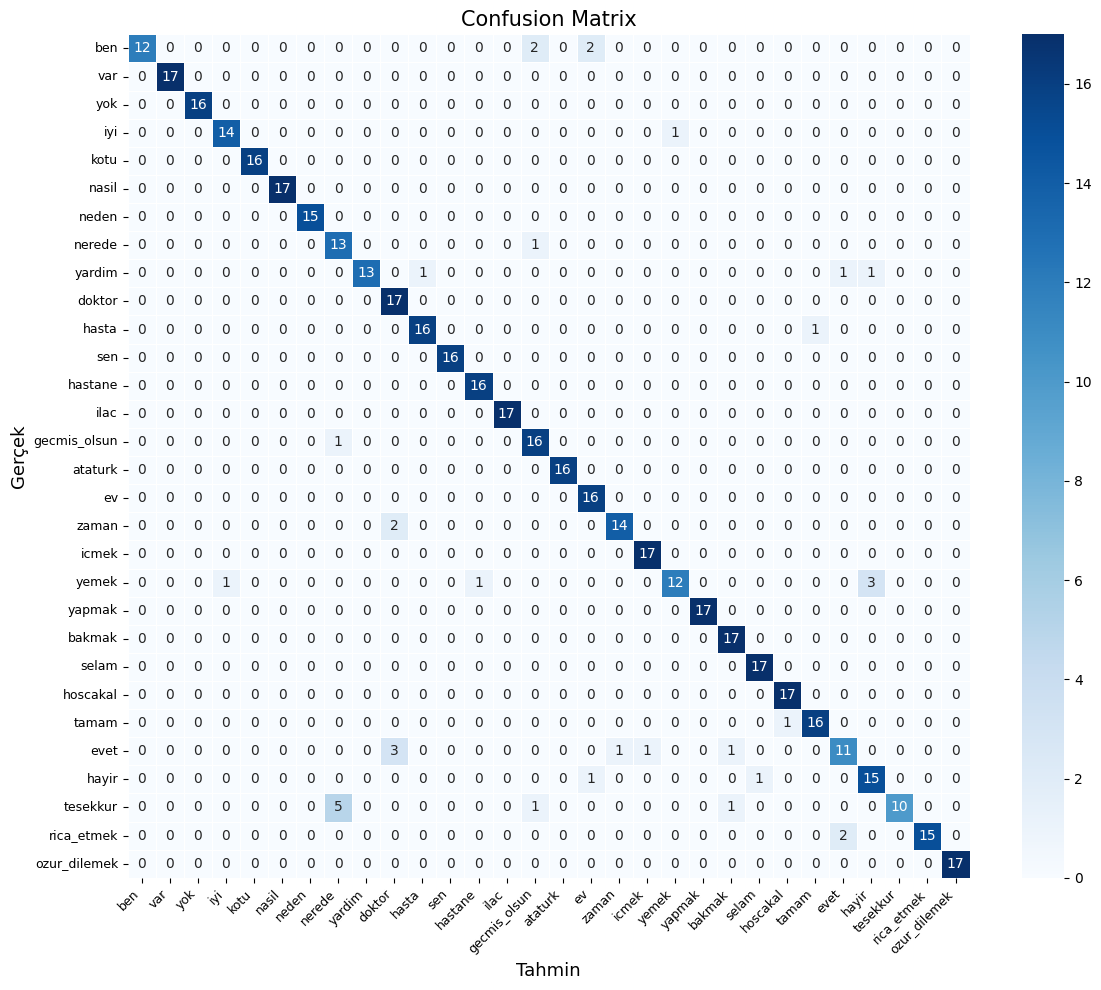

Kaydedildi: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44/confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [c.split('_', 1)[-1] for c in classes]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5
)

ax.set_xlabel('Tahmin', fontsize=13)
ax.set_ylabel('Gerçek', fontsize=13)
ax.set_title('Confusion Matrix', fontsize=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# Drive'a kaydet
cm_path = os.path.join(EXP_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {cm_path}')

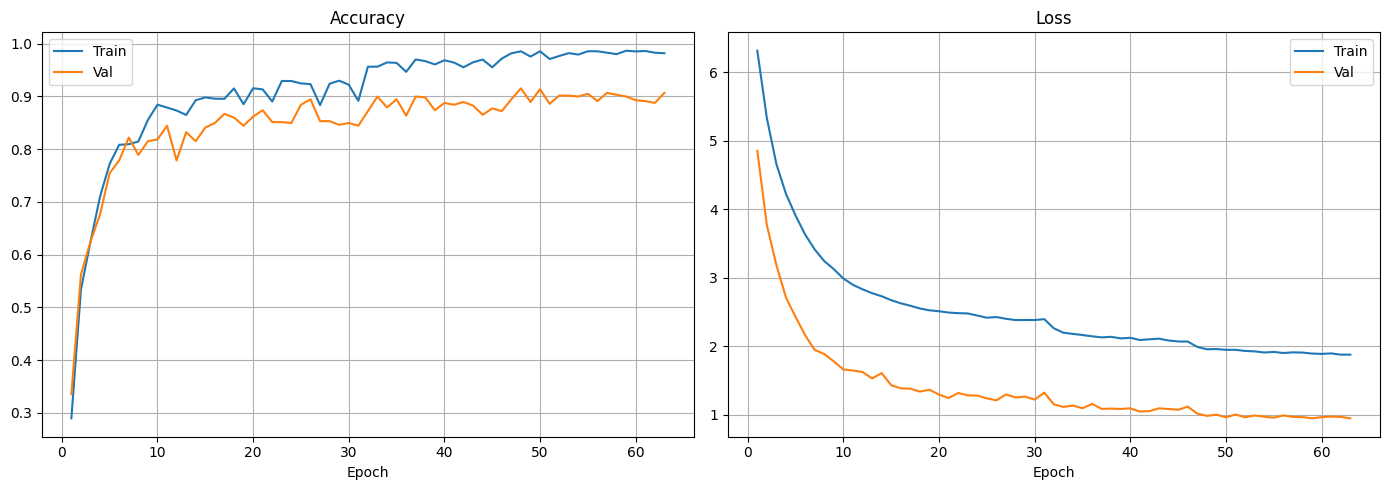

Kaydedildi: /content/drive/MyDrive/Nöron-Ağları-Proje/ErenDataset/experiments/2026-05-26_21-17-44/training_curves.png


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = [e['epoch'] for e in cb_list[-1].history]

# Accuracy
axes[0].plot(epochs, [e['train']['accuracy'] for e in cb_list[-1].history], label='Train')
axes[0].plot(epochs, [e['val']['accuracy']   for e in cb_list[-1].history], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs, [e['train']['loss'] for e in cb_list[-1].history], label='Train')
axes[1].plot(epochs, [e['val']['loss']   for e in cb_list[-1].history], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
curves_path = os.path.join(EXP_DIR, 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {curves_path}')